# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [5]:
import pandas as pd
import plotly.express as px
import numpy as np
import plotly.graph_objects as go

# Dataset: Airbnb London Listings

df = pd.read_csv('../data/airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [2]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


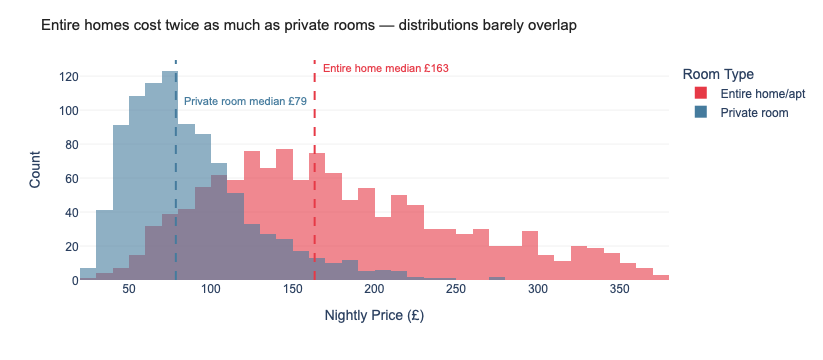

In [3]:
# Task 1 — Histogram: Entire home vs Private room price distributions

two_types = df_cap[df_cap['room_type'].isin(['Entire home/apt', 'Private room'])]

median_entire  = two_types[two_types['room_type'] == 'Entire home/apt']['price'].median()
median_private = two_types[two_types['room_type'] == 'Private room']['price'].median()

COLOR_MAP = {
    'Entire home/apt': '#E63946',
    'Private room':    '#457B9D'
}

fig = px.histogram(
    two_types,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    nbins=50,
    color_discrete_map=COLOR_MAP,
    labels={'price': 'Nightly Price (£)', 'room_type': 'Room Type'}
)

fig.add_vline(x=median_entire, line_dash='dash', line_color='#E63946', line_width=2)
fig.add_annotation(x=median_entire, y=1, yref='paper',
    text=f"Entire home median £{median_entire:.0f}",
    showarrow=False, xanchor='left', xshift=6,
    font=dict(family='Arial', size=11, color='#E63946'))

fig.add_vline(x=median_private, line_dash='dash', line_color='#457B9D', line_width=2)
fig.add_annotation(x=median_private, y=0.85, yref='paper',
    text=f"Private room median £{median_private:.0f}",
    showarrow=False, xanchor='left', xshift=6,
    font=dict(family='Arial', size=11, color='#457B9D'))

fig.update_layout(
    title=dict(text="Entire homes cost twice as much as private rooms — distributions barely overlap",
        font=dict(family='Arial', size=15, color='#222222')),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial'),
    xaxis=dict(showgrid=False, showline=False),
    yaxis=dict(showgrid=True, gridcolor='#F0F0F0', showline=False, title='Count')
)
fig.show()


## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

Two most active boroughs: ['Hackney', 'Tower Hamlets']


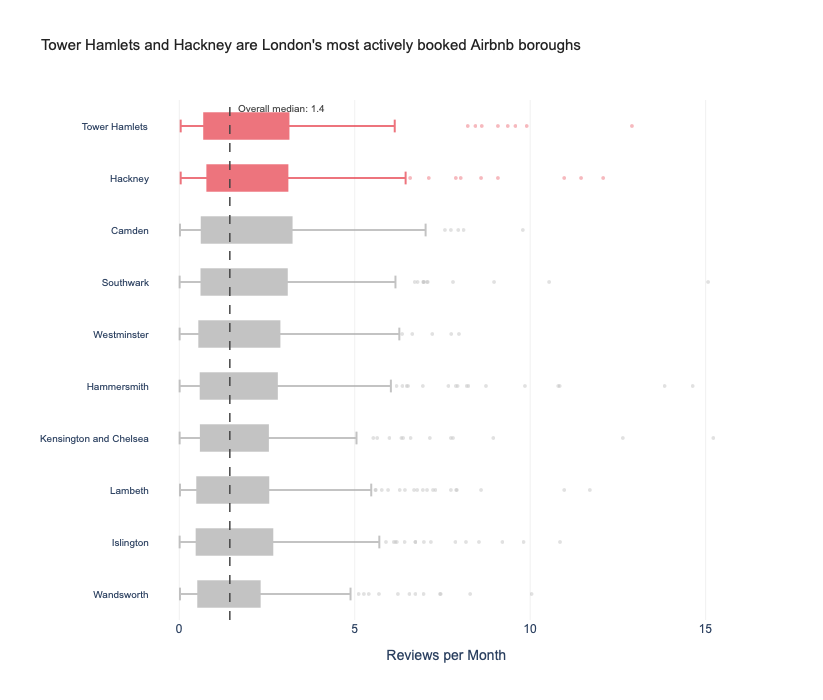

In [6]:
# Task 2 — Box plot: listing activity by borough

# Filter out inactive listings (zero reviews)
active = df_cap[df_cap['reviews_per_month'] > 0].copy()

# Sort boroughs by median reviews per month
borough_order = (
    active.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=True)
    .index.tolist()
)

# Top 2 most active boroughs
top2 = borough_order[-2:]
print("Two most active boroughs:", top2)

HIGHLIGHT_COLOR = '#E63946'
DEFAULT_COLOR   = '#AAAAAA'

fig = go.Figure()

for borough in borough_order:
    bdata = active[active['neighbourhood'] == borough]['reviews_per_month']
    color = HIGHLIGHT_COLOR if borough in top2 else DEFAULT_COLOR

    fig.add_trace(go.Box(
        x=bdata,
        name=borough,
        orientation='h',
        marker_color=color,
        line_color=color,
        fillcolor=color,
        opacity=0.7,
        boxpoints='outliers',
        marker=dict(size=4, opacity=0.5),
        showlegend=False
    ))

overall_median = active['reviews_per_month'].median()
fig.add_vline(x=overall_median, line_dash='dash', line_color='#444444', line_width=1.5)
fig.add_annotation(
    x=overall_median, y=1, yref='paper',
    text=f"Overall median: {overall_median:.1f}",
    showarrow=False, xanchor='left', xshift=6,
    font=dict(family='Arial', size=10, color='#444444')
)

fig.update_layout(
    title=dict(
        text=f"{top2[-1]} and {top2[-2]} are London's most actively booked Airbnb boroughs",
        font=dict(family='Arial', size=15, color='#222222')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial'),
    xaxis=dict(title='Reviews per Month', showgrid=True, gridcolor='#F0F0F0', showline=False, zeroline=False),
    yaxis=dict(showgrid=False, showline=False, tickfont=dict(family='Arial', size=10)),
    height=700,
    margin=dict(l=150)
)

fig.show()